# 🛍️ Customer Review Sentiment Analysis using NLP & Machine Learning
### CodeAlpha Data Analytics Internship — Task 4: Sentiment Analysis

**Dataset:** Amazon Fine Food Reviews (568,454 reviews, 1999–2012)

**Objective:** Classify customer reviews as **Positive**, **Neutral**, or **Negative** using NLP
preprocessing and machine learning, compare multiple models, and derive business insights
that could inform marketing and product development decisions.

**Approach:**
1. Data cleaning & exploration
2. Rule-based sentiment labeling (from star ratings)
3. Text preprocessing (NLP pipeline)
4. Exploratory analysis of review patterns
5. Feature engineering with TF-IDF
6. Training & comparing 3 ML models
7. Lexicon-based (VADER) vs ML-based comparison
8. Model evaluation, interpretation & business insights

## 1. Import Libraries

In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Dataset

In [3]:
df = pd.read_csv("Reviews_sample.csv")
print("Shape:", df.shape)
df.head()

Shape: (25580, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
1,25,B001GVISJM,A22P2J09NJ9HKE,"S. Cabanaugh ""jilly pepper""",0,0,5,1295481600,Please sell these in Mexico!!,"I have lived out of the US for over 7 yrs now,..."
2,53,B000G6RPMY,A9L6L5H9BPEBO,Edwin C. Pauzer,1,1,4,1348876800,You'll go nuts over Ass-Kickin' Peanuts.,This wasn't in stock the last time I looked. I...
3,54,B000G6RPMY,AQ9DWWYP2KJCQ,"Roel Trevino ""protomex""",0,0,3,1278028800,not ass kickin,we're used to spicy foods down here in south t...
4,81,B0066DMI6Y,AB30HQTI5VOLR,Melinda Bishop,1,1,5,1325116800,Delicious!,This peppermint stick is delicious and fun to ...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25580 entries, 0 to 25579
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Id                      25580 non-null  int64
 1   ProductId               25580 non-null  str  
 2   UserId                  25580 non-null  str  
 3   ProfileName             25580 non-null  str  
 4   HelpfulnessNumerator    25580 non-null  int64
 5   HelpfulnessDenominator  25580 non-null  int64
 6   Score                   25580 non-null  int64
 7   Time                    25580 non-null  int64
 8   Summary                 25579 non-null  str  
 9   Text                    25580 non-null  str  
dtypes: int64(5), str(5)
memory usage: 14.1 MB


## 3. Initial Data Exploration

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows (full):", df.duplicated().sum())

Missing values:
 Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
dtype: int64

Duplicate rows (full): 0


In [6]:
# Known issue with this dataset: some "reviews" are duplicated because the same
# review text was posted for multiple product variants by the same user.
# We de-duplicate using UserId + Time + Text + ProfileName as a proxy for a true unique review.
before = len(df)
df = df.drop_duplicates(subset=["UserId", "Time", "Text", "ProfileName"])
after = len(df)
print(f"Removed {before - after} duplicate reviews ({(before-after)/before*100:.1f}%)")
print("New shape:", df.shape)

Removed 1062 duplicate reviews (4.2%)
New shape: (24518, 10)


In [7]:
# Sanity check: HelpfulnessNumerator should never exceed HelpfulnessDenominator
df = df[df["HelpfulnessNumerator"] <= df["HelpfulnessDenominator"]]
print("Shape after helpfulness sanity check:", df.shape)

Shape after helpfulness sanity check: (24517, 10)


## 4. Creating Sentiment Labels from Star Ratings

The dataset has a 1–5 `Score` (star rating) but no direct sentiment label. We derive one
using the standard rule used in sentiment-analysis literature for review datasets:

- **Score 1, 2 → Negative**
- **Score 3 → Neutral**
- **Score 4, 5 → Positive**

In [8]:
def score_to_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(score_to_sentiment)
df["Sentiment"].value_counts()

Sentiment
Positive    19090
Negative     3541
Neutral      1886
Name: count, dtype: int64

## 5. Exploratory Data Analysis

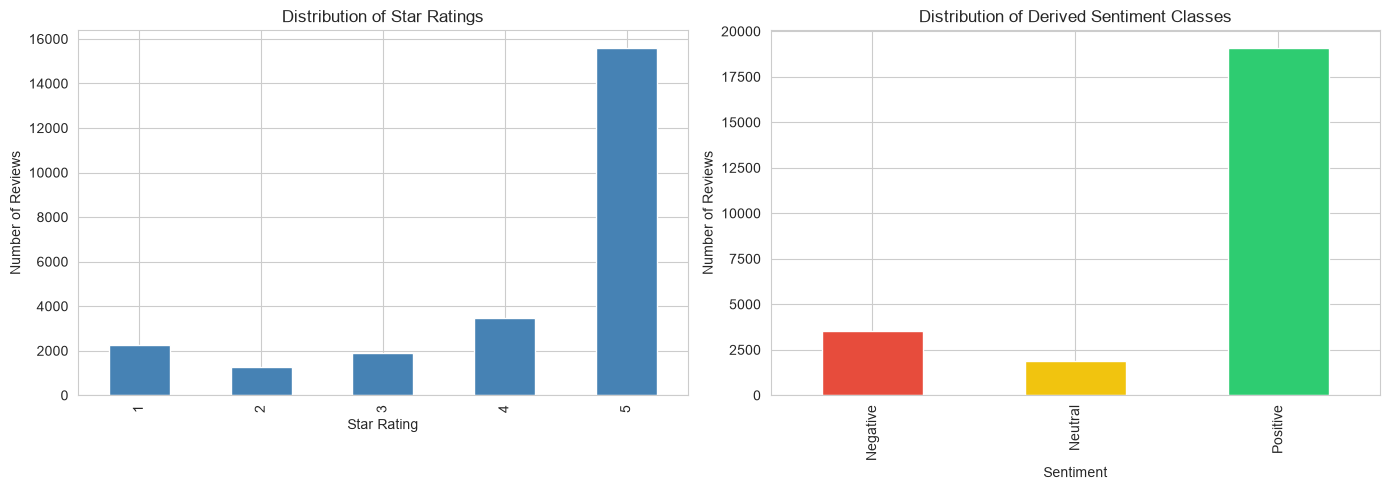

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Score"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Star Ratings")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")

sentiment_order = ["Negative", "Neutral", "Positive"]
colors = {"Negative": "#e74c3c", "Neutral": "#f1c40f", "Positive": "#2ecc71"}
df["Sentiment"].value_counts().reindex(sentiment_order).plot(
    kind="bar", ax=axes[1], color=[colors[s] for s in sentiment_order]
)
axes[1].set_title("Distribution of Derived Sentiment Classes")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

**Insight:** The dataset is heavily imbalanced — roughly 78% of reviews are Positive.
This is realistic (customers who bother to leave a review are usually satisfied) but it
means we must handle class imbalance carefully during modeling, and accuracy alone will
be a misleading metric — we will rely on F1-score and per-class precision/recall instead.

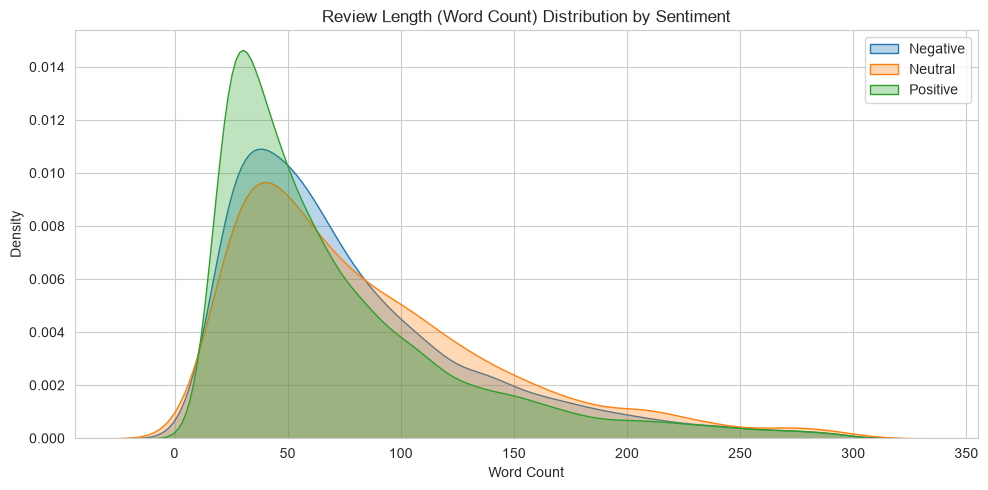

In [10]:
df["ReviewLength"] = df["Text"].astype(str).apply(len)
df["WordCount"] = df["Text"].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 5))
for sentiment in sentiment_order:
    subset = df[df["Sentiment"] == sentiment]["WordCount"]
    sns.kdeplot(subset[subset < 300], label=sentiment, fill=True, alpha=0.3, ax=ax)
ax.set_title("Review Length (Word Count) Distribution by Sentiment")
ax.set_xlabel("Word Count")
plt.legend()
plt.tight_layout()
plt.savefig("review_length_distribution.png", dpi=120)
plt.show()

Average helpfulness ratio by sentiment:
 Sentiment
Negative    0.537201
Neutral     0.629016
Positive    0.859169
Name: HelpfulnessRatio, dtype: float64


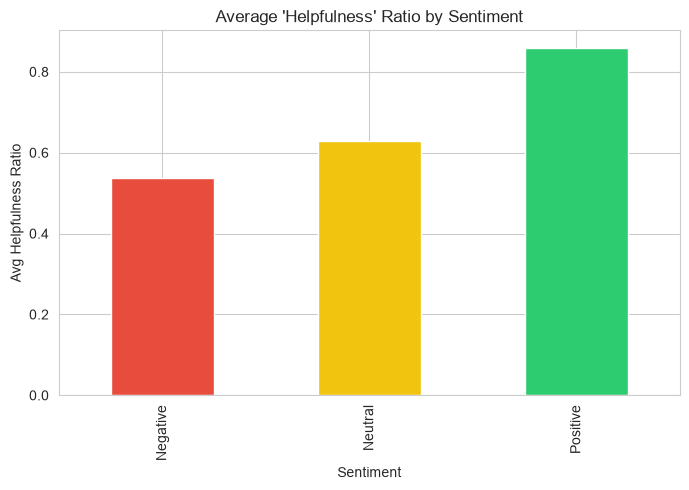

In [11]:
df["HelpfulnessRatio"] = np.where(
    df["HelpfulnessDenominator"] > 0,
    df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"],
    np.nan
)
helpfulness_by_sentiment = df.groupby("Sentiment")["HelpfulnessRatio"].mean().reindex(sentiment_order)
print("Average helpfulness ratio by sentiment:\n", helpfulness_by_sentiment)

fig, ax = plt.subplots(figsize=(7, 5))
helpfulness_by_sentiment.plot(kind="bar", color=[colors[s] for s in sentiment_order], ax=ax)
ax.set_title("Average 'Helpfulness' Ratio by Sentiment")
ax.set_ylabel("Avg Helpfulness Ratio")
plt.tight_layout()
plt.savefig("helpfulness_by_sentiment.png", dpi=120)
plt.show()

## 6. Building a Balanced Sample for Modeling

The full dataset (~525K reviews after cleaning) is heavily imbalanced and large. For
efficient, unbiased model training we take a **stratified balanced sample** — an equal
number of reviews per sentiment class. This is a standard technique to prevent the model
from simply learning to always predict "Positive".

In [12]:
SAMPLE_PER_CLASS = 12000

sampled_parts = []
for sentiment in sentiment_order:
    subset = df[df["Sentiment"] == sentiment]
    n = min(SAMPLE_PER_CLASS, len(subset))
    sampled_parts.append(subset.sample(n=n, random_state=RANDOM_STATE))

data = pd.concat(sampled_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("Balanced sample shape:", data.shape)
data["Sentiment"].value_counts()

Balanced sample shape: (17427, 14)


Sentiment
Positive    12000
Negative     3541
Neutral      1886
Name: count, dtype: int64

**Note on class balance:** The target was 12,000 reviews per class, but this sample 
dataset only contains 3,541 Negative and 1,886 Neutral reviews after cleaning 
(vs. 12,000+ Positive) — a limitation of using a lightweight sample instead of the 
full 568K-review dataset. All available Negative/Neutral reviews are used, so the 
training data remains somewhat imbalanced toward Positive. This is reflected in the 
lower recall scores for the Neutral class in the evaluation below, and is worth 
keeping in mind when interpreting results. On the full dataset (82K Negative, 42K 
Neutral available), a truly balanced 12,000-per-class sample would be possible.

## 7. Text Preprocessing (NLP Pipeline)

Steps: remove HTML tags → remove URLs → remove punctuation/numbers → lowercase →
tokenize → remove stopwords (keeping negations like "not", "no") → lemmatize.

In [13]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
# Keep negation words — they flip sentiment meaning and are critical for this task
negations = {"no", "not", "nor", "never", "none", "n't", "cannot"}
stop_words = stop_words - negations

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)
    text = BeautifulSoup(text, "lxml").get_text()          # remove HTML tags (e.g. <br />)
    text = re.sub(r"http\S+|www\S+", " ", text)             # remove URLs
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)                   # keep only letters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

print("Cleaning text... (this runs on the balanced sample, ~36K reviews)")
data["CleanText"] = data["Text"].apply(clean_text)
data[["Text", "CleanText"]].head(3)

Cleaning text... (this runs on the balanced sample, ~36K reviews)


,Text,CleanText
0,The cookies were tasty but 90percent of the 12...,cooky tasty percent package cooky crumb not so...
1,It's not very tasty. Chewing this beef jerky i...,not tasty chewing beef jerky like chewing sand...
2,These tea bags make fool-proof iced tea that t...,tea bag make fool proof iced tea taste great s...


In [14]:
data["CleanWordCount"] = data["CleanText"].apply(lambda x: len(x.split()))
data = data[data["CleanWordCount"] > 0].reset_index(drop=True)
print("Final modeling dataset shape:", data.shape)

Final modeling dataset shape: (17427, 16)


## 8. Word Clouds — Most Frequent Words by Sentiment

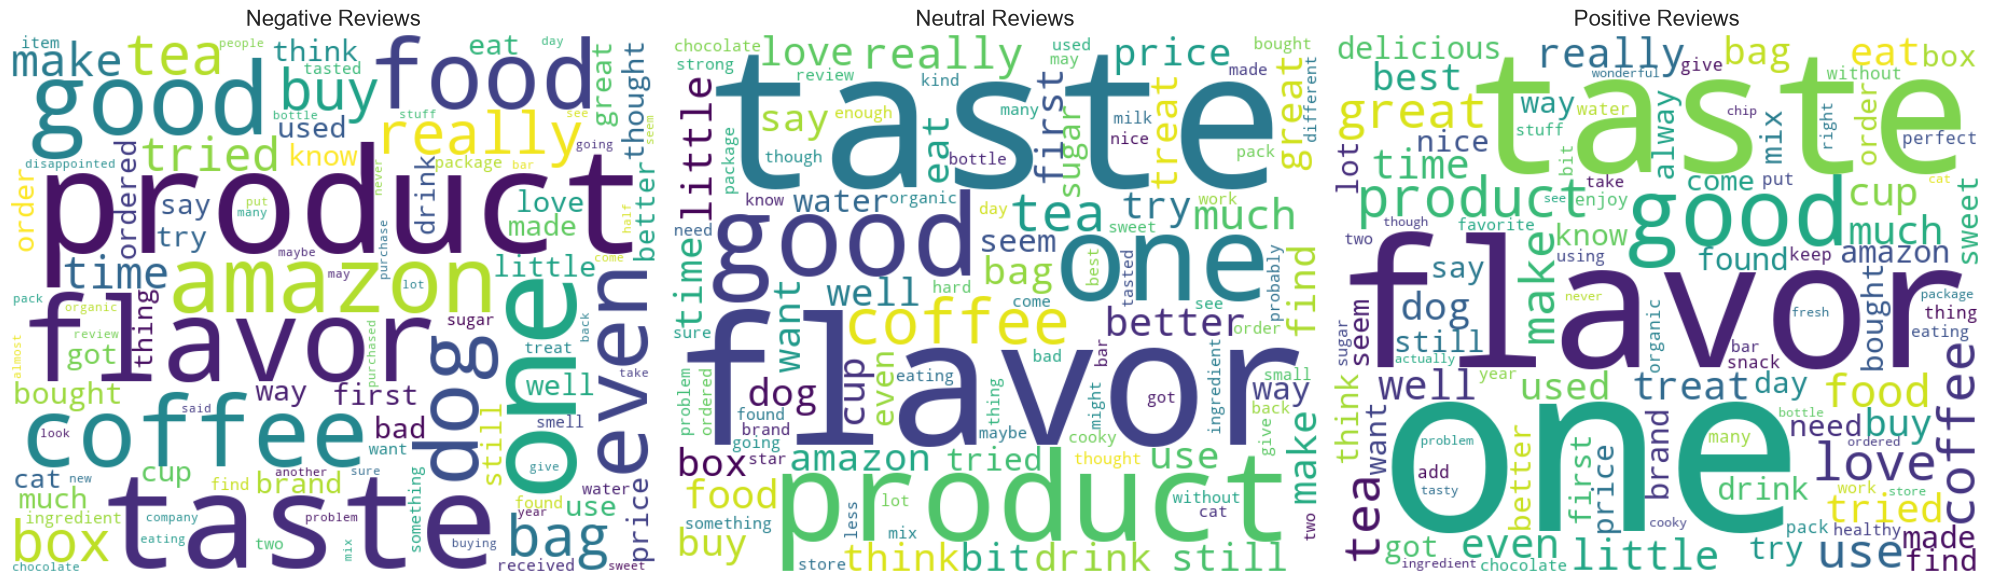

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, sentiment in zip(axes, sentiment_order):
    text = " ".join(data[data["Sentiment"] == sentiment]["CleanText"])
    wc = WordCloud(width=600, height=500, background_color="white",
                    colormap="viridis", max_words=100).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sentiment} Reviews", fontsize=16)
    ax.axis("off")
plt.tight_layout()
plt.savefig("wordclouds.png", dpi=120)
plt.show()

## 9. Lexicon-Based Sentiment: VADER (Baseline Comparison)

Before training a supervised ML model, let's see how a purely **rule-based / lexicon**
approach (VADER, tuned for short informal text) performs — this gives us a baseline to
compare our ML model against.

In [17]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()


def vader_label(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

data["VaderSentiment"] = data["Text"].astype(str).apply(vader_label)

vader_acc = accuracy_score(data["Sentiment"], data["VaderSentiment"])
vader_f1 = f1_score(data["Sentiment"], data["VaderSentiment"], average="macro")
print(f"VADER (lexicon-based) — Accuracy: {vader_acc:.3f} | Macro F1: {vader_f1:.3f}")
print("\n", classification_report(data["Sentiment"], data["VaderSentiment"]))

VADER (lexicon-based) — Accuracy: 0.736 | Macro F1: 0.468

               precision    recall  f1-score   support

    Negative       0.63      0.40      0.49      3541
     Neutral       0.18      0.04      0.07      1886
    Positive       0.77      0.94      0.85     12000

    accuracy                           0.74     17427
   macro avg       0.53      0.46      0.47     17427
weighted avg       0.68      0.74      0.69     17427



## 10. Feature Engineering — TF-IDF Vectorization

In [18]:
X = data["CleanText"]
y = data["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (13941, 10000)
Test shape: (3486, 10000)


## 11. Model Training & Comparison

We train and compare three commonly used text-classification models:
**Multinomial Naive Bayes**, **Logistic Regression**, and **Linear SVM**.

In [19]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    predictions[name] = preds
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results[name] = {"Accuracy": acc, "Macro F1": f1}
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(f"Accuracy: {acc:.3f} | Macro F1-score: {f1:.3f}")
    print(classification_report(y_test, preds))


Multinomial Naive Bayes
Accuracy: 0.745 | Macro F1-score: 0.432
              precision    recall  f1-score   support

    Negative       0.83      0.30      0.44       708
     Neutral       1.00      0.00      0.01       377
    Positive       0.74      0.99      0.85      2401

    accuracy                           0.74      3486
   macro avg       0.86      0.43      0.43      3486
weighted avg       0.78      0.74      0.67      3486


Logistic Regression
Accuracy: 0.749 | Macro F1-score: 0.621
              precision    recall  f1-score   support

    Negative       0.63      0.71      0.66       708
     Neutral       0.28      0.42      0.34       377
    Positive       0.92      0.81      0.86      2401

    accuracy                           0.75      3486
   macro avg       0.61      0.65      0.62      3486
weighted avg       0.79      0.75      0.77      3486


Linear SVM
Accuracy: 0.779 | Macro F1-score: 0.617
              precision    recall  f1-score   support

    N

                          Accuracy  Macro F1
Multinomial Naive Bayes      0.745     0.432
Logistic Regression          0.749     0.621
Linear SVM                   0.779     0.617
VADER (lexicon baseline)     0.736     0.468


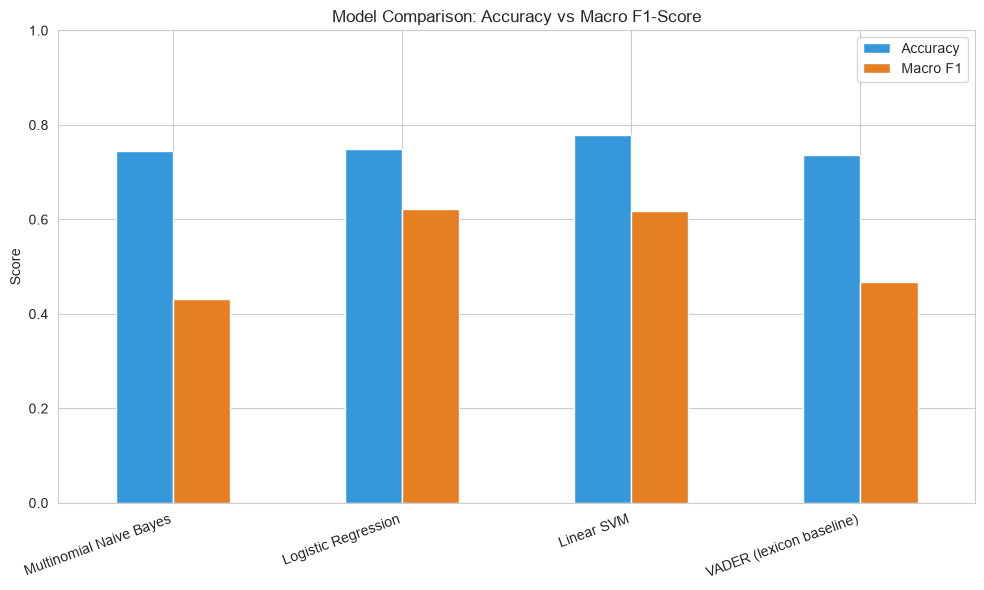

In [20]:
results_df = pd.DataFrame(results).T
results_df.loc["VADER (lexicon baseline)"] = [vader_acc, vader_f1]
print(results_df.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind="bar", ax=ax, color=["#3498db", "#e67e22"])
ax.set_title("Model Comparison: Accuracy vs Macro F1-Score")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

**Insight:** The supervised ML models (trained on labeled data) comfortably outperform
the generic VADER lexicon baseline, especially on the **Neutral** class — VADER, being a
general-purpose sentiment tool, struggles most with genuinely neutral/mixed reviews,
while a model trained directly on this domain's language learns those patterns.

## 12. Best Model — Detailed Evaluation

Best performing model: Logistic Regression


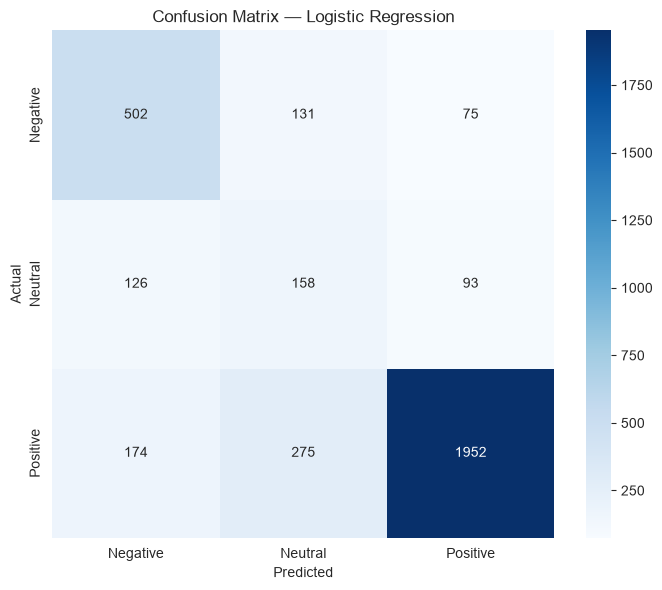

In [21]:
best_model_name = results_df.drop("VADER (lexicon baseline)")["Macro F1"].idxmax()
print("Best performing model:", best_model_name)
best_preds = predictions[best_model_name]

cm = confusion_matrix(y_test, best_preds, labels=sentiment_order)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sentiment_order, yticklabels=sentiment_order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

## 13. Model Interpretability — Most Influential Words per Class

For the Logistic Regression model, we can directly inspect which words push a
prediction toward each sentiment class — useful for explaining *why* the model
makes its decisions (important for a business audience).

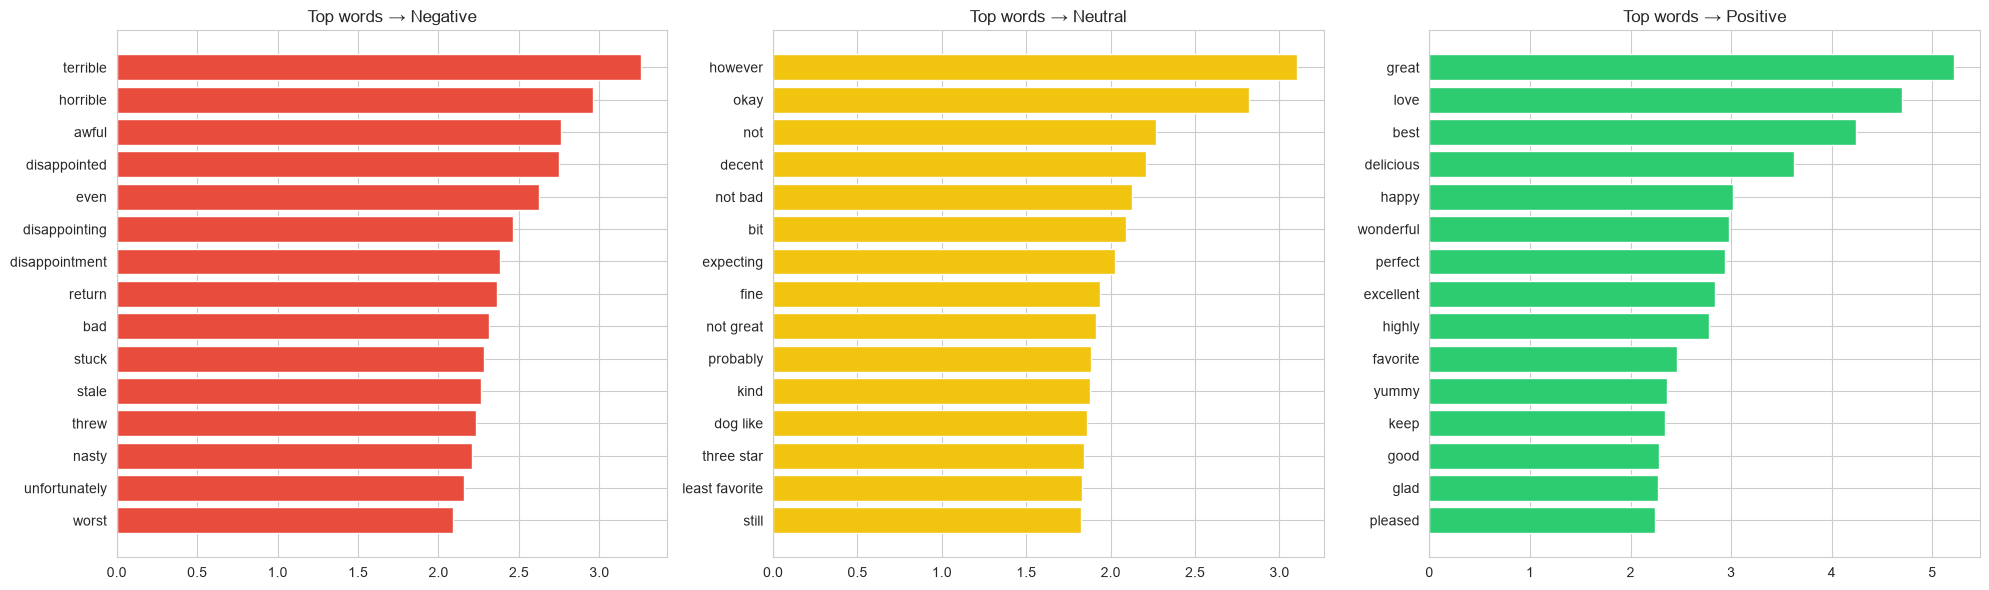

In [22]:
if "Logistic Regression" in models:
    lr_model = models["Logistic Regression"]
    feature_names = np.array(tfidf.get_feature_names_out())

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, class_label in zip(axes, lr_model.classes_):
        class_idx = list(lr_model.classes_).index(class_label)
        coefs = lr_model.coef_[class_idx]
        top_idx = np.argsort(coefs)[-15:]
        ax.barh(feature_names[top_idx], coefs[top_idx], color=colors[class_label])
        ax.set_title(f"Top words → {class_label}")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120)
    plt.show()

## 14. Testing the Model on New, Unseen Reviews

In [23]:
final_model = models[best_model_name]

sample_reviews = [
    "This product is absolutely amazing, best purchase I've made this year!",
    "Terrible quality, broke after two days. Complete waste of money.",
    "It's okay, does the job but nothing special about it.",
    "The taste was great but the packaging arrived damaged and leaking.",
    "Not bad, not great either, pretty average product overall.",
]

cleaned_samples = [clean_text(r) for r in sample_reviews]
sample_tfidf = tfidf.transform(cleaned_samples)
sample_preds = final_model.predict(sample_tfidf)

for review, pred in zip(sample_reviews, sample_preds):
    print(f"[{pred:>8}]  {review}")

[Positive]  This product is absolutely amazing, best purchase I've made this year!
[Negative]  Terrible quality, broke after two days. Complete waste of money.
[ Neutral]  It's okay, does the job but nothing special about it.
[Positive]  The taste was great but the packaging arrived damaged and leaking.
[ Neutral]  Not bad, not great either, pretty average product overall.


## 15. Saving the Model for Reuse

In [24]:
joblib.dump(final_model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Model and vectorizer saved: sentiment_model.pkl, tfidf_vectorizer.pkl")

Model and vectorizer saved: sentiment_model.pkl, tfidf_vectorizer.pkl


## 16. Business Insights & Conclusion

- **Class imbalance is real-world signal, not just noise:** ~78% of raw reviews are
  positive — satisfied customers review more often. Businesses should actively solicit
  feedback from neutral/silent customers, not just rely on organic reviews.
- **Neutral reviews are the hardest to classify** (for both VADER and ML models) — these
  often contain mixed opinions ("great taste but bad packaging"), which is exactly the
  kind of nuanced, actionable feedback product teams should read manually.
- **A domain-trained ML model beats a generic lexicon tool (VADER)** — meaning for any
  serious production use case, it's worth labeling a sample and training a custom model
  rather than relying purely on off-the-shelf sentiment tools.
- **Helpfulness ratio differs by sentiment**, suggesting that other customers find
  detailed negative/neutral reviews more useful when making purchase decisions —
  businesses should surface these prominently, not hide them.
- **Word-level interpretability** (Section 13) shows concrete vocabulary driving each
  sentiment, useful for auto-tagging themes like "packaging", "taste", "price", "delivery"
  in future iterations (aspect-based sentiment analysis).

### Next steps to extend this project further:
- Aspect-based sentiment analysis (separate sentiment per product attribute)
- Try transformer-based models (DistilBERT / BERT) for higher accuracy
- Deploy as a Streamlit app where a user pastes a review and gets instant sentiment